# 🧠 Rethinking the Baseline: GDP & Longevity
**By** Siem Mebrahtu
### Can economic prosperity explain differences in life expectancy?

**Data source:** World Bank Open Data API  
**Countries:** 20 selected countries  
**Analysis year:** 2024 — the latest common complete year across the three indicators used


**Research question:** How strongly is GDP per capita associated with life expectancy, and which countries perform above or below the relationship predicted by a GDP-based model?

**Workflow:** API collection → cleaning → visualization → correlation → regression → residual analysis → interpretation


## 📊 Executive Summary

| Metric | Result |
|---|---:|
| Countries analyzed | **20** |
| Analysis year | **2024** |
| Pearson correlation (raw GDP) | **0.722** |
| Pearson correlation (log GDP) | **0.885** |
| Spearman correlation | **0.839** |
| Linear model R² | **0.784** |
| Quadratic model R² | **0.795** |

GDP per capita and life expectancy show a strong positive association in this selected 2024 sample. The results are observational and **do not establish causation**.


## 1. Data Cleaning & Feature Transformation
The data is collected from the World Bank Open Data API and saved as a Kaggle dataset(linked here).

Indicators:
- GDP per capita (current US$): `NY.GDP.PCAP.CD`
- Life expectancy at birth (years): `SP.DYN.LE00.IN`
- Population, total: `SP.POP.TOTL`

Raw economic data exhibits heavy right-skewness. To linearize exponential income scaling, we apply a $\log_{10}$ transformation to GDP per capita:

$$\text{log\_GDP\_per\_capita} = \log_{10}(\text{GDP\_per\_capita})$$


**Note:** Missing records are removed prior to transformation to ensure feature alignment across all pipelines.

## 2. Data Cleaning & Analysis Year

The raw API response is reshaped into one row per country-year. Missing observations are excluded from the complete-case analysis.

The raw API can contain newer year labels for some indicators while the actual observation is missing. We therefore select the **latest common year with complete observations for all 20 countries and all three indicators**.



In [1]:
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

countries = ["USA","CHN","IND","JPN","DEU","GBR","FRA","BRA","CAN","AUS",
             "KOR","MEX","IDN","TUR","ZAF","NGA","EGY","KEN","ETH","RWA"]

indicators = {
    "GDP_per_capita": "NY.GDP.PCAP.CD",
    "Life_expectancy": "SP.DYN.LE00.IN",
    "Population": "SP.POP.TOTL"
}

kaggle_path = "/kaggle/input/datasets/siemmebrahtu/raw-world-bank-data/raw_world_bank_data.csv"
local_path = "data/raw_world_bank_data.csv"   # used when running outside Kaggle (e.g. a cloned GitHub repo)
dataset_path = kaggle_path if os.path.exists(kaggle_path) else local_path
df = pd.read_csv(dataset_path)

print("REAL WORLD DATA COLLECTED")
print("Rows:", len(df))

if len(df) == 0:
    print("\n*** NO DATA RETRIEVED ***")
    print("Check your kernel is working.")
    print("Make sure this work environment fine and re-run this cell before continuing.")
else:
    print("Countries:", df["country"].nunique())
    print("Indicators:", df["indicator"].unique())
    print("Year range:", df["year"].min(), "-", df["year"].max())

REAL WORLD DATA COLLECTED
Rows: 3933
Countries: 20
Indicators: ['GDP_per_capita' 'Life_expectancy' 'Population']
Year range: 1960 - 2025


In [2]:
analysis = df.pivot_table(
    index=["country","country_code","year"],
    columns="indicator",
    values="value"
).reset_index()

analysis = analysis.dropna(
    subset=["GDP_per_capita","Life_expectancy","Population"]
)

year_counts = analysis.groupby("year")["country"].nunique()
complete_years = year_counts[year_counts == len(countries)].index

if len(complete_years) == 0:
    raise ValueError(
        "No year has complete data for all 20 countries. "
        "Check data/raw_world_bank_data.csv to see what was actually retrieved."
    )

analysis_year = int(complete_years.max())
latest = analysis[analysis["year"] == analysis_year].copy()


print("Usable observations:", len(analysis))
print("Countries:", latest["country"].nunique())
print("Latest common complete year:", analysis_year)


Usable observations: 1293
Countries: 20
Latest common complete year: 2024


With the two cells above run successfully, the data is ready for analysis.

**Note:** Run the previous two cells without errors before continuing — the cells below assume `latest` already exists.


## 3. Main Visualization — GDP vs Life Expectancy

GDP per capita is shown on a logarithmic scale because income varies substantially between countries. Bubble size represents population.


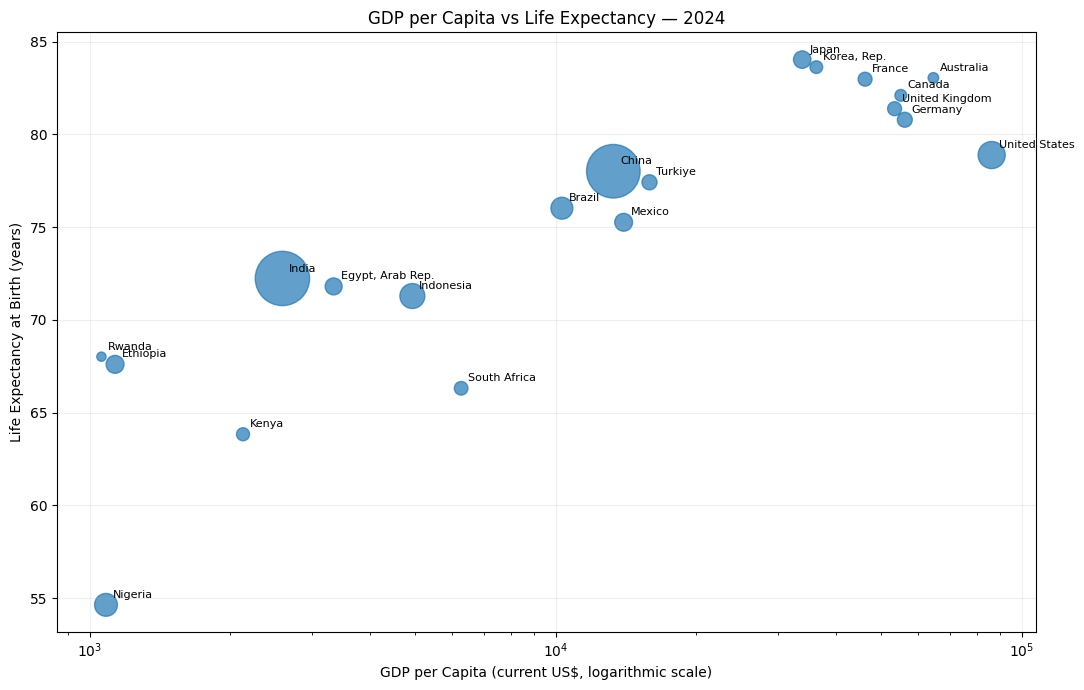

In [3]:
plt.figure(figsize=(11,7))
plt.scatter(
    latest["GDP_per_capita"],
    latest["Life_expectancy"],
    s=latest["Population"]/latest["Population"].max()*1500+30,
    alpha=0.7
)
for _, row in latest.iterrows():
    plt.annotate(row["country"], (row["GDP_per_capita"],row["Life_expectancy"]),
                 xytext=(5,5), textcoords="offset points", fontsize=8)
plt.xscale("log")
plt.xlabel("GDP per Capita (current US$, logarithmic scale)")
plt.ylabel("Life Expectancy at Birth (years)")
plt.title(f"GDP per Capita vs Life Expectancy — {analysis_year}")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


This chart gives a first look at the relationship before any modeling.

**Reading the chart:**
1. Bubble size (population) doesn't track cleanly with GDP per capita or life expectancy — large and small bubbles appear across the whole range, so population isn't a strong confounder here.
2. Setting population aside, GDP per capita and life expectancy appear to follow a broadly linear pattern.
3. A few countries sit noticeably off that pattern — GDP per capita alone doesn't predict their life expectancy well. Section 9 investigates these.


## 4. Life Expectancy Across Countries


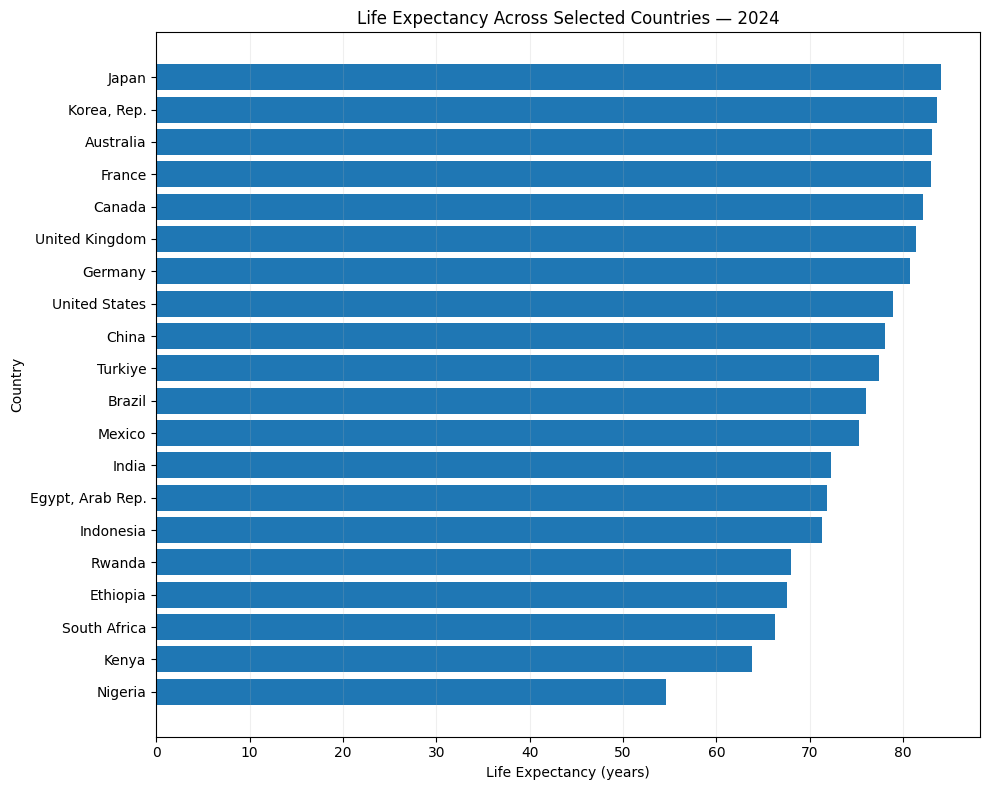

In [4]:
life_sorted = latest.sort_values("Life_expectancy")
plt.figure(figsize=(10,8))
plt.barh(life_sorted["country"], life_sorted["Life_expectancy"])
plt.xlabel("Life Expectancy (years)")
plt.ylabel("Country")
plt.title(f"Life Expectancy Across Selected Countries — {analysis_year}")
plt.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()


The graph above shows the countries having high Life Expectancy and the countries having low Life Expectancy which we will later inspect.

## 5. GDP per Capita Across Countries


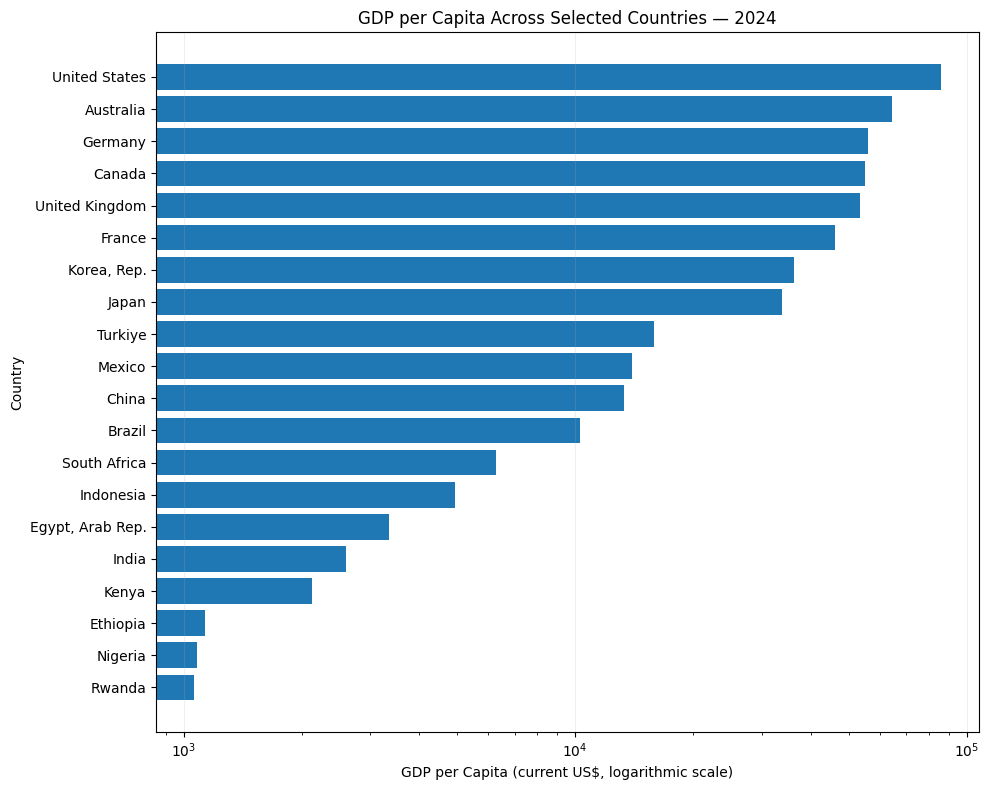

In [5]:
gdp_sorted = latest.sort_values("GDP_per_capita")
plt.figure(figsize=(10,8))
plt.barh(gdp_sorted["country"], gdp_sorted["GDP_per_capita"])
plt.xscale("log")
plt.xlabel("GDP per Capita (current US$, logarithmic scale)")
plt.ylabel("Country")
plt.title(f"GDP per Capita Across Selected Countries — {analysis_year}")
plt.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()


The graph above shows the countries having high GDP per capita and the countries having low GDP per capita which we will also inspect later.

## 6. Correlation Analysis

Pearson measures linear association; Spearman measures monotonic rank association.


In [6]:
pearson = latest["GDP_per_capita"].corr(latest["Life_expectancy"], method="pearson")
spearman = latest["GDP_per_capita"].corr(latest["Life_expectancy"], method="spearman")

print(f"Pearson correlation:  {pearson:.3f}")
print(f"Spearman correlation: {spearman:.3f}")

latest["log_GDP_per_capita"] = np.log10(latest["GDP_per_capita"])
corr_log = latest["log_GDP_per_capita"].corr(latest["Life_expectancy"])
print(f"Correlation using log GDP per capita: {corr_log:.3f}")


Pearson correlation:  0.722
Spearman correlation: 0.839
Correlation using log GDP per capita: 0.885


**Interpretation:**
1. GDP data is heavily right-skewed — a handful of countries have very high GDP per capita compared to the rest, which can distort a raw Pearson correlation. Taking $\log_{10}$ of GDP per capita corrects this. The log-GDP correlation is 0.885, the strongest of the three measures below, and the one to lead with.
2. The raw-GDP Pearson correlation is 0.722. It still reflects a strong positive linear relationship, but it understates the true association because it's computed on the skewed, untransformed variable.
3. The Spearman correlation of 0.839 uses only the ranks of each variable rather than their exact values, so it's less sensitive to skew than raw Pearson, though it also discards some information compared to the log-transformed correlation. It agrees with the other two measures that the association is strong and monotonic.
`None of these three values imply causation.`


## 7. Regression Modeling

We compare linear and quadratic regression using log GDP per capita. The goal is descriptive: does a simple nonlinear term improve model fit?


In [7]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = latest[["log_GDP_per_capita"]]
y = latest["Life_expectancy"]

linear = LinearRegression().fit(X, y)
linear_pred = linear.predict(X)
linear_r2 = r2_score(y, linear_pred)

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
quadratic = LinearRegression().fit(X_poly, y)
quadratic_pred = quadratic.predict(X_poly)
quadratic_r2 = r2_score(y, quadratic_pred)

print(f"Linear R²: {linear_r2:.3f}")
print(f"Quadratic R²: {quadratic_r2:.3f}")
print(f"R² improvement: {quadratic_r2-linear_r2:.3f}")


Linear R²: 0.784
Quadratic R²: 0.795
R² improvement: 0.011


**Interpretation:**
1. The linear model's R² of 0.784 means log-GDP per capita explains about 78.4% of the variation in life expectancy across these 20 countries, **in-sample**.
2. The quadratic model's R² of 0.795 means the same using a curved fit instead of a straight line: explains about 79.5% of the variation, again in-sample.
3. The 0.011 gap is the extra variation the quadratic term explains over the linear one — about 1.1 percentage points. Because both numbers come from the same data the models were fit to, this gap alone can't tell us whether the quadratic term is a real pattern or noise. Section 7b checks that properly before either model is used for the residual analysis.



## 7b. Model Validation

In-sample R² can't tell us whether the quadratic term is a real improvement or just noise, since both models were judged on the same 20 points they were fit to. Two checks instead:

1. **F-test** — does the quadratic term explain significantly more variance than chance alone would predict?
2. **Leave-one-out cross-validation** — how well does each model predict a country it did *not* see while fitting? With only 20 points this is a far more honest error estimate than in-sample R², and it's compared against a naive baseline (always predict the sample mean).

Whichever model wins **both** checks is the one used for the residual analysis in Section 9 — not automatically whichever has the higher in-sample R².



In [8]:
# Model validation: is the quadratic term real, or noise?
from scipy import stats
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.dummy import DummyRegressor
from sklearn.pipeline import make_pipeline

n = len(latest)
rss_linear = np.sum((y - linear_pred) ** 2)
rss_quad = np.sum((y - quadratic_pred) ** 2)
df_linear = n - 2   # intercept + 1 slope
df_quad = n - 3      # intercept + 2 slopes

f_stat = ((rss_linear - rss_quad) / (df_linear - df_quad)) / (rss_quad / df_quad)
f_pvalue = stats.f.sf(f_stat, df_linear - df_quad, df_quad)

print(f"F-test for the quadratic term: F = {f_stat:.2f}, p = {f_pvalue:.3f}")
if f_pvalue < 0.05:
    print("-> The quadratic term explains significantly more variance than chance would predict.")
else:
    print("-> The quadratic term's extra fit is not statistically distinguishable from chance at n=20.")

loo = LeaveOneOut()
baseline_pred  = cross_val_predict(DummyRegressor(strategy="mean"), X, y, cv=loo)
loo_linear_pred = cross_val_predict(LinearRegression(), X, y, cv=loo)
loo_quad_pred   = cross_val_predict(
    make_pipeline(PolynomialFeatures(degree=2), LinearRegression()), X, y, cv=loo
)

def rmse(pred):
    return np.sqrt(np.mean((y.to_numpy() - pred) ** 2))

print("\nLeave-one-out RMSE (lower is better; each country predicted by a model that never saw it):")
print(f"  Baseline (predict the mean):  {rmse(baseline_pred):.2f} years")
print(f"  Linear model:                 {rmse(loo_linear_pred):.2f} years")
print(f"  Quadratic model:              {rmse(loo_quad_pred):.2f} years")

# Prefer the quadratic model only if BOTH checks favor it; default to the simpler linear model otherwise.
use_quadratic = (f_pvalue < 0.05) and (rmse(loo_quad_pred) < rmse(loo_linear_pred))
final_model_name = "quadratic" if use_quadratic else "linear"
final_pred = quadratic_pred if use_quadratic else linear_pred

print(f"\nFinal model selected for the residual analysis: {final_model_name}")



F-test for the quadratic term: F = 0.93, p = 0.350
-> The quadratic term's extra fit is not statistically distinguishable from chance at n=20.

Leave-one-out RMSE (lower is better; each country predicted by a model that never saw it):
  Baseline (predict the mean):  8.12 years
  Linear model:                 4.15 years
  Quadratic model:              4.45 years

Final model selected for the residual analysis: linear


## 7c. Relationship Validation via TSM

Given that both GDP and Life Expectancy tend to increase over time, it's crucial to ensure that any observed relationship isn't spurious due to common trends. Time Series Modeling helps validate the true underlying association.

First, we'll prepare the data for panel analysis and check for stationarity in individual series using the Augmented Dickey-Fuller (ADF) test. Then, we'll run a Panel OLS regression to explicitly control for unobserved country-specific heterogeneity and time-specific trends.

In [9]:
!pip install linearmodels -q  #if you are using kaggle make sure your internet is toggled on
from statsmodels.tsa.stattools import adfuller
import warnings
# Suppress specific FutureWarning from statsmodels.tsa.stattools.adfuller
warnings.filterwarnings(
    "ignore",
    message="adfuller currently returns a plain tuple whose length depends on the store and autolag arguments.",
    category=FutureWarning
)

# Re-load df if this cell is run standalone (e.g. after a kernel restart).
if 'df' not in globals():
    df = pd.read_csv(dataset_path)

# Prepare data for panel analysis from the original df
# Need to rename columns to 'entity' and 'time' for PanelOLS MultiIndex expectation
panel_df = df.copy()
panel_df = panel_df.rename(columns={'country': 'entity', 'year': 'time'})

# Pivot the table to get 'GDP_per_capita', 'Life_expectancy' as columns
panel_df = panel_df.pivot_table(
    index=['entity', 'time'],
    columns='indicator',
    values='value'
).reset_index()


panel_df = panel_df.set_index(['entity', 'time'])

# Log transform GDP per capita
panel_df['log_GDP_per_capita'] = np.log10(panel_df['GDP_per_capita'])

# Drop rows with any missing values
panel_df = panel_df.dropna(subset=['GDP_per_capita', 'Life_expectancy', 'log_GDP_per_capita'])


print("*** ADF Test for Stationarity (GDP per Capita and Life Expectancy) ***\n")


for country in panel_df.index.get_level_values('entity').unique():
    print(f"Country: {country}")
    country_data = panel_df.loc[country]

    #for GDP
    gdp_series = country_data['GDP_per_capita'].dropna()
    if len(gdp_series) > 5: # ADF test requires at least 5 observations.
        gdp_adf_result = adfuller(gdp_series)
        print(f"  GDP per Capita: ADF Stat={gdp_adf_result[0]:.2f}, p-value={gdp_adf_result[1]:.3f}")
    else:
        print("  GDP per Capita: Not enough data for ADF test.")

    #for Life Expectancy
    le_series = country_data['Life_expectancy'].dropna()
    if len(le_series) > 5: # ADF test requires at least 5 observations
        le_adf_result = adfuller(le_series)

        print(f"  Life Expectancy: ADF Stat={le_adf_result[0]:.2f}, p-value={le_adf_result[1]:.3f}")
    else:
        print("  Life Expectancy: Not enough data for ADF test.")
    print("-" * 30)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 33.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 3.8 MB/s eta 0:00:00
*** ADF Test for Stationarity (GDP per Capita and Life Expectancy) ***

Country: Australia
  GDP per Capita: ADF Stat=-0.12, p-value=0.947
  Life Expectancy: ADF Stat=-0.71, p-value=0.845
------------------------------
Country: Brazil
  GDP per Capita: ADF Stat=-0.85, p-value=0.803
  Life Expectancy: ADF Stat=-1.10, p-value=0.717
------------------------------
Country: Canada
  GDP per Capita: ADF Stat=0.25, p-value=0.975
  Life Expectancy: ADF Stat=-1.59, p-value=0.490
------------------------------
Country: China
  GDP per Capita: ADF Stat=-4.00, p-value=0.001
  Life Expectancy: ADF Stat=-6.49, p-value=0.000
------------------------------
Country: Egypt, Arab Rep.
  GDP per Capita: ADF Stat=3.90, p-value=1.000
  Life Expectancy: ADF Stat=-2.98, p-value=0.037
------------------------------
Country: Ethiopia
  GDP per Capita:

The Augmented Dickey-Fuller (ADF) test results indicate the stationarity of the time series for each country. A low p-value (typically < 0.05) suggests that the series is stationary, meaning its statistical properties (like mean and variance) do not change over time. Many macroeconomic and demographic series are non-stationary, exhibiting trends, which can lead to spurious regression results if not accounted for. This preliminary check informs our choice of panel regression model.


**What the test actually shows:** most countries fail to reject the unit-root null for both series (p > 0.05) — only a handful (e.g. China, Japan, Turkiye for life expectancy) look stationary on their own. That's expected for series this short and trending, and it's exactly why we don't rely on the raw levels alone below.


Next, we proceed with a Panel OLS regression to model the relationship, explicitly controlling for both entity (country) and time fixed effects to account for non-stationarity and common trends.


In [10]:
!pip install linearmodels -q
from linearmodels.panel import PanelOLS
import statsmodels.api as sm

y = panel_df['Life_expectancy']
X = sm.add_constant(panel_df['log_GDP_per_capita'])

# Create and fit the PanelOLS model
# entity_effects=True controls for unobserved country-specific characteristics
# time_effects=True controls for unobserved common trends over time (e.g., global health improvements)
# cov_type='clustered' with cluster_entity=True handles potential heteroskedasticity and cross-sectional dependence
mod = PanelOLS(y, X, entity_effects=True, time_effects=True)
panel_res = mod.fit(cov_type='clustered', cluster_entity=True)

print(panel_res)

                          PanelOLS Estimation Summary                           
Dep. Variable:        Life_expectancy   R-squared:                        0.0648
Estimator:                   PanelOLS   R-squared (Between):              0.4762
No. Observations:                1293   R-squared (Within):               0.4945
Date:                Wed, Sep 30 2026   R-squared (Overall):              0.4818
Time:                        01:59:39   Log-likelihood                   -3278.0
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      83.635
Entities:                          20   P-value                           0.0000
Avg Obs:                       64.650   Distribution:                  F(1,1208)
Min Obs:                       58.000                                           
Max Obs:                       65.000   F-statistic (robust):             6.0413
                            

### Panel Regression Results Interpretation

The Panel OLS regression, including both entity and time fixed effects, gives a more robust estimate of the relationship between log GDP per capita and life expectancy than the cross-sectional analysis in Sections 6–7, because it removes each country's fixed characteristics (culture, geography, starting point) and each year's global trend (e.g. worldwide gains in medicine) before looking at the remaining association.

**The result:** after these controls, the coefficient on `log_GDP_per_capita` is **+4.66 years** (p = 0.014, clustered by country). In plain terms: within the same country, a roughly 10x increase in GDP per capita is associated with about 4.7 additional years of life expectancy, even after removing shared global trends and each country's fixed characteristics. The relationship survives the strictest check in this notebook — it is not simply an artifact of richer countries and later years both having higher life expectancy.

**Between vs. within — the more interesting finding.** The model's overall R² is only 0.065, far below the 0.88 log-GDP correlation reported in Section 6. That's not a contradiction; it's the point of running this model. Most of the strong correlation in Section 6 is a **between-country** pattern (richer countries simply tend to have higher life expectancy). The **within-country** effect — a given country getting richer over time — is real and statistically significant, but far more modest. Both are true at once; a fixed-effects model is what lets us tell them apart.

**A caveat worth stating plainly:** the ADF results above show most of these series are non-stationary in levels. Country and time fixed effects remove level differences and common trends, which is the standard first line of defense, but they do not by themselves rule out spurious regression between two trending series as rigorously as, say, a first-differenced or cointegration-based model would. The significant result here is reassuring, not definitive — see Limitations.


## 8. Nonlinear Relationship

This plot shows the quadratic curve for illustration, even though the linear model is selected for the residual analysis in Section 7b — it's here to visualize what a small nonlinear term looks like on this data, not to assert that it's the better model.


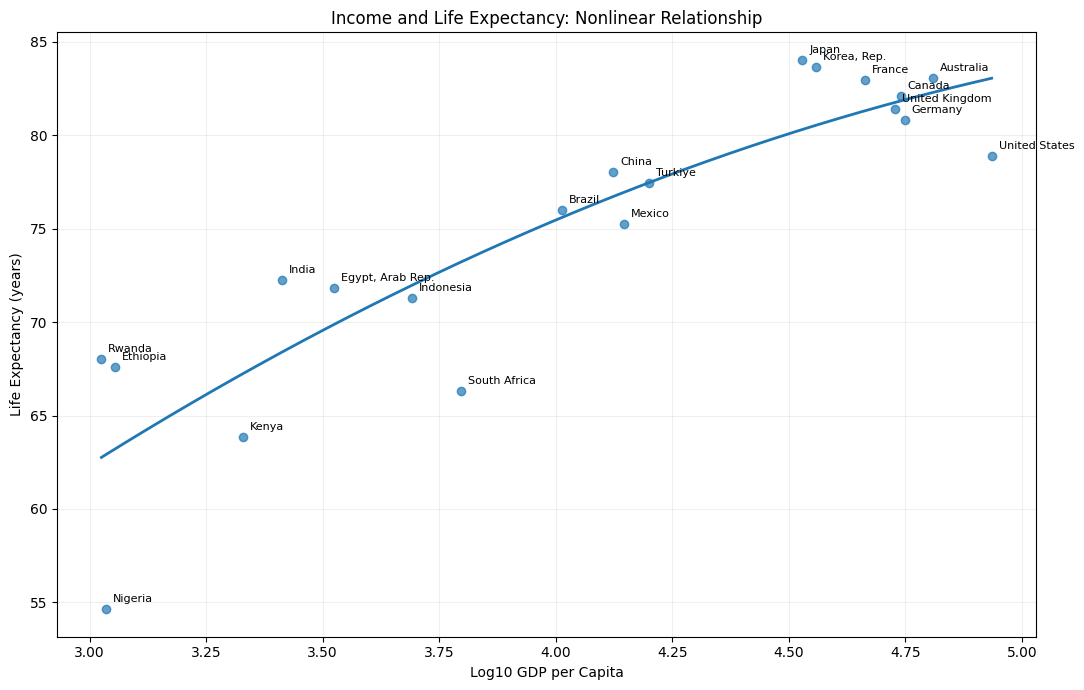

In [11]:
x_range = pd.DataFrame(
    np.linspace(latest["log_GDP_per_capita"].min(),latest["log_GDP_per_capita"].max(),200),
    columns=["log_GDP_per_capita"]
)
predicted = quadratic.predict(poly.transform(x_range))

plt.figure(figsize=(11,7))
plt.scatter(latest["log_GDP_per_capita"], latest["Life_expectancy"], alpha=0.7)
plt.plot(x_range["log_GDP_per_capita"],predicted,linewidth=2)

for _, row in latest.iterrows():
    plt.annotate(row["country"], (row["log_GDP_per_capita"],row["Life_expectancy"]),
                 xytext=(5,5), textcoords="offset points", fontsize=8)

plt.xlabel("Log10 GDP per Capita")
plt.ylabel("Life Expectancy (years)")
plt.title("Income and Life Expectancy: Nonlinear Relationship")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


## 9. Residual Analysis

Residual = observed life expectancy − model-predicted life expectancy.

Based on our results in Section 7b this section uses the linear model for analysis

Positive residuals indicate higher observed life expectancy than predicted; negative residuals indicate lower. These are **investigation leads, not causal explanations**.


In [12]:
#Incase of change in data-set this analysis is done by choosing the best model from 7b
latest["predicted_life_expectancy"] = final_pred
latest["residual"] = latest["Life_expectancy"] - latest["predicted_life_expectancy"]

print(f"Residuals computed from the {final_model_name} model (selected in Section 7b).")

print("\nHIGHER LIFE EXPECTANCY THAN PREDICTED")
display(latest.nlargest(5,"residual")[
    ["country","GDP_per_capita","Life_expectancy","predicted_life_expectancy","residual"]
])

print("\nLOWER LIFE EXPECTANCY THAN PREDICTED")
display(latest.nsmallest(5,"residual")[
    ["country","GDP_per_capita","Life_expectancy","predicted_life_expectancy","residual"]
])


top5 = latest.nlargest(5, "residual")
bottom5 = latest.nsmallest(5, "residual")
top_str = ", ".join(f"{r.country} ({r.residual:+.2f} years)" for r in top5.itertuples())
bottom_str = ", ".join(f"{r.country} ({r.residual:+.2f} years)" for r in bottom5.itertuples())


Residuals computed from the linear model (selected in Section 7b).

HIGHER LIFE EXPECTANCY THAN PREDICTED


indicator,country,GDP_per_capita,Life_expectancy,predicted_life_expectancy,residual
592,India,2591.991661,72.235000,68.120867,4.114133
1054,Rwanda,1059.937093,68.017000,63.965584,4.051416
724,Japan,33797.101429,84.036341,80.053713,3.982629
394,Ethiopia,1133.882797,67.603000,64.278959,3.324041
856,"Korea, Rep.",36238.639908,83.629268,80.377834,3.251434



LOWER LIFE EXPECTANCY THAN PREDICTED


indicator,country,GDP_per_capita,Life_expectancy,predicted_life_expectancy,residual
988,Nigeria,1084.160418,54.635000,64.070585,-9.435585
1120,South Africa,6267.186814,66.312000,72.223567,-5.911567
1318,United States,86169.664158,78.890244,84.402891,-5.512647
790,Kenya,2133.461934,63.834000,67.216218,-3.382218
526,Germany,56103.732318,80.792683,82.408858,-1.616175


## 10. Observed vs Predicted


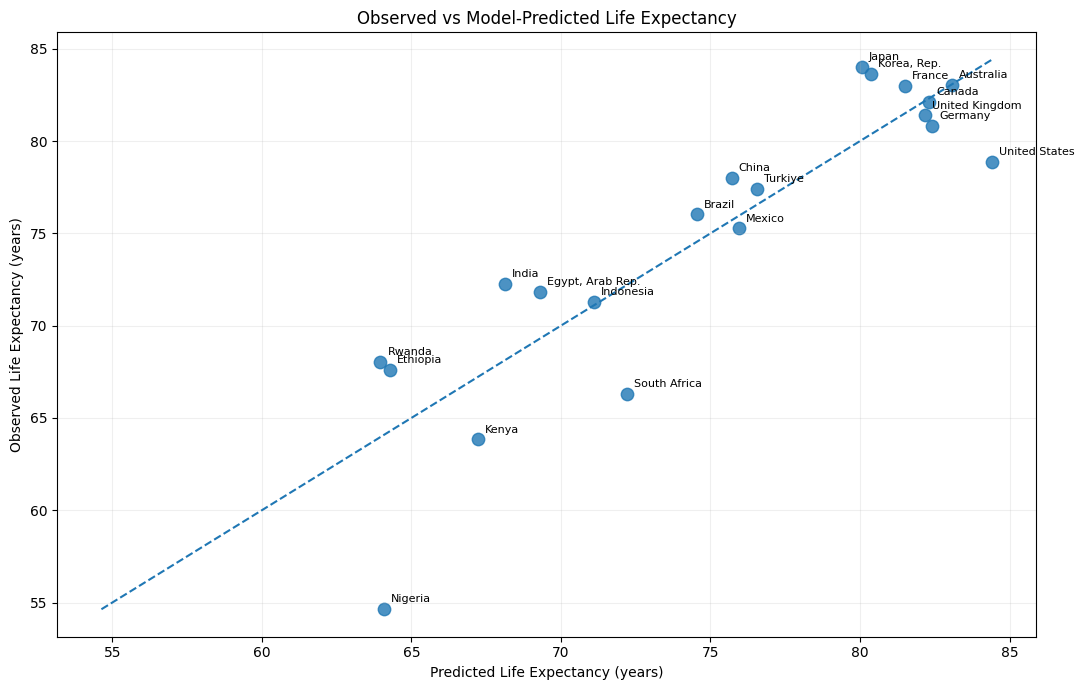

In [13]:
plt.figure(figsize=(11,7))
plt.scatter(latest["predicted_life_expectancy"], latest["Life_expectancy"],
            s=80, alpha=0.8)

lo = min(latest["predicted_life_expectancy"].min(), latest["Life_expectancy"].min())
hi = max(latest["predicted_life_expectancy"].max(), latest["Life_expectancy"].max())
plt.plot([lo,hi],[lo,hi], linestyle="--")

for _, row in latest.iterrows():
    plt.annotate(row["country"],
                 (row["predicted_life_expectancy"],row["Life_expectancy"]),
                 xytext=(5,5), textcoords="offset points", fontsize=8)

plt.xlabel("Predicted Life Expectancy (years)")
plt.ylabel("Observed Life Expectancy (years)")
plt.title("Observed vs Model-Predicted Life Expectancy")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


## 10b. Interactive Dashboard (Plotly)

Everything below rebuilds the same six panels using `plotly` instead of `matplotlib` — same data, same models (`latest`, `quadratic`, `poly`, `pearson`, `spearman`, `linear_r2`, `quadratic_r2` all reused from the cells above, nothing recomputed) — but every chart is now:

- **Hoverable** — hovering any point/bar shows the country name and exact values instead of relying on tiny label text
- **Zoomable/pannable** — useful once you want to inspect the cluster of mid-income countries closely
- **Exportable as a standalone HTML file** — so it can be embedded directly, no server needed


The final cell also adds a country spotlight control built with Plotly's own dropdown menus (not `ipywidgets`), so it keeps working when the notebook is viewed statically — e.g. on a public Kaggle page — rather than only in a live kernel session.


In [14]:
from IPython.display import HTML

card_html=f"""
<div style="background:#0b1e33;color:#eaf2fb;padding:22px 28px;border-radius:14px;
            font-family:-apple-system,Segoe UI,sans-serif;max-width:1000px;">
  <div style="font-size:22px;font-weight:700;margin-bottom:4px;">🌍 Beyond GDP — Key Results ({analysis_year})</div>
  <div style="color:#8fb4d9;margin-bottom:16px;">Interactive rebuild of the dashboard — hover any chart below for details</div>
  <div style="display:flex;gap:28px;flex-wrap:wrap;">
    <div><div style="font-size:26px;font-weight:700;color:#4fd1c5;">{latest['country'].nunique()}</div><div style="color:#8fb4d9;">Countries</div></div>
    <div><div style="font-size:26px;font-weight:700;color:#4fd1c5;">{pearson:.3f}</div><div style="color:#8fb4d9;">Pearson r</div></div>
    <div><div style="font-size:26px;font-weight:700;color:#4fd1c5;">{spearman:.3f}</div><div style="color:#8fb4d9;">Spearman ρ</div></div>
    <div><div style="font-size:26px;font-weight:700;color:#4fd1c5;">{linear_r2:.3f}</div><div style="color:#8fb4d9;">Linear R²</div></div>
    <div><div style="font-size:26px;font-weight:700;color:#f6ad55;">{quadratic_r2:.3f}</div><div style="color:#8fb4d9;">Quadratic R²</div></div>
  </div>
</div>
"""
HTML(card_html)

In [15]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

resid_sorted = latest.sort_values("residual")
life_sorted_pl = latest.sort_values("Life_expectancy")
gdp_sorted_pl = latest.sort_values("GDP_per_capita")

fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=(
        "GDP per Capita vs Life Expectancy",
        "Life Expectancy by Country",
        "GDP per Capita by Country (log scale)",
        "Nonlinear Fit: Log GDP vs Life Expectancy",
        "Observed vs Predicted Life Expectancy",
        "Residuals — Who Over/Under-performs GDP?"
    ),
    specs=[[{"type":"scatter"},{"type":"bar"},{"type":"bar"}],
           [{"type":"scatter"},{"type":"scatter"},{"type":"bar"}]],
    horizontal_spacing=0.08, vertical_spacing=0.14
)

# 1. GDP vs Life Expectancy bubble chart, colored by residual
fig.add_trace(go.Scatter(
    x=latest["GDP_per_capita"], y=latest["Life_expectancy"],
    mode="markers", text=latest["country"],
    marker=dict(
        size=latest["Population"]/latest["Population"].max()*60+8,
        color=latest["residual"], colorscale="RdYlGn", cmin=-10, cmax=10,
        line=dict(width=1, color="white"), showscale=False
    ),
    hovertemplate="<b>%{text}</b><br>GDP/capita: $%{x:,.0f}<br>Life exp: %{y:.1f} yrs<extra></extra>",
    showlegend=False
), row=1, col=1)
fig.update_xaxes(type="log", title_text="GDP per Capita (US$, log)", row=1, col=1)

# 2. Life expectancy bar
fig.add_trace(go.Bar(
    x=life_sorted_pl["Life_expectancy"], y=life_sorted_pl["country"],
    orientation="h", marker_color="#4fd1c5",
    hovertemplate="<b>%{y}</b>: %{x:.1f} yrs<extra></extra>", showlegend=False
), row=1, col=2)

# 3. GDP bar (log)
fig.add_trace(go.Bar(
    x=gdp_sorted_pl["GDP_per_capita"], y=gdp_sorted_pl["country"],
    orientation="h", marker_color="#f6ad55",
    hovertemplate="<b>%{y}</b>: $%{x:,.0f}<extra></extra>", showlegend=False
), row=1, col=3)
fig.update_xaxes(type="log", row=1, col=3)

# 4. Nonlinear fit
x_range_pl = pd.DataFrame(
    np.linspace(latest["log_GDP_per_capita"].min(), latest["log_GDP_per_capita"].max(), 200),
    columns=["log_GDP_per_capita"]
)
pred_pl = quadratic.predict(poly.transform(x_range_pl))
fig.add_trace(go.Scatter(
    x=latest["log_GDP_per_capita"], y=latest["Life_expectancy"], mode="markers",
    text=latest["country"], marker=dict(color="#63b3ed", size=9),
    hovertemplate="<b>%{text}</b><extra></extra>", showlegend=False
), row=2, col=1)
fig.add_trace(go.Scatter(
    x=x_range_pl["log_GDP_per_capita"], y=pred_pl, mode="lines",
    line=dict(color="#4fd1c5", width=3), hoverinfo="skip", showlegend=False
), row=2, col=1)

# 5. Observed vs Predicted
lo_v = min(latest["predicted_life_expectancy"].min(), latest["Life_expectancy"].min())
hi_v = max(latest["predicted_life_expectancy"].max(), latest["Life_expectancy"].max())
fig.add_trace(go.Scatter(
    x=latest["predicted_life_expectancy"], y=latest["Life_expectancy"], mode="markers",
    text=latest["country"], marker=dict(color="#b794f4", size=9),
    hovertemplate="<b>%{text}</b><br>Predicted: %{x:.1f}<br>Observed: %{y:.1f}<extra></extra>",
    showlegend=False
), row=2, col=2)
fig.add_trace(go.Scatter(
    x=[lo_v, hi_v], y=[lo_v, hi_v], mode="lines",
    line=dict(color="white", width=1, dash="dash"), hoverinfo="skip", showlegend=False
), row=2, col=2)

# 6. Residuals — replaces the redundant duplicate bubble chart with something new:
#    a direct view of who beats/misses their GDP-predicted life expectancy
colors = ["#48bb78" if v >= 0 else "#fc8181" for v in resid_sorted["residual"]]
fig.add_trace(go.Bar(
    x=resid_sorted["residual"], y=resid_sorted["country"],
    orientation="h", marker_color=colors,
    hovertemplate="<b>%{y}</b>: %{x:+.2f} yrs vs model<extra></extra>", showlegend=False
), row=2, col=3)

fig.update_layout(
    template="plotly_dark", height=820, width=1300,
    title=f"Beyond GDP — Interactive Dashboard ({analysis_year})",
    margin=dict(t=90)
)
fig.show()

### Country Spotlight

A dropdown control — pick any country and it's highlighted against the full GDP/life-expectancy relationship. Built with Plotly's own dropdown menus instead of `ipywidgets`, so it works in a static/published view of the notebook, not only in a live kernel session.


In [16]:
import plotly.graph_objects as go

names_sorted = sorted(latest["country"].unique())

def spotlight_style(selected):
    colors = ["#f6ad55" if c == selected else "#4a5568" for c in latest["country"]]
    sizes = [22 if c == selected else 10 for c in latest["country"]]
    row = latest[latest["country"] == selected].iloc[0]
    title = (f"{selected}: ${row['GDP_per_capita']:,.0f} GDP/capita, "
             f"{row['Life_expectancy']:.1f} yrs life expectancy "
             f"({row['residual']:+.2f} yrs vs. {final_model_name} model)")
    return colors, sizes, title

c0, s0, t0 = spotlight_style(names_sorted[0])
spotlight = go.Figure(go.Scatter(
    x=latest["GDP_per_capita"], y=latest["Life_expectancy"], mode="markers",
    text=latest["country"],
    marker=dict(color=c0, size=s0, line=dict(width=1, color="white")),
    hovertemplate="<b>%{text}</b><br>GDP/capita: $%{x:,.0f}<br>Life exp: %{y:.1f} yrs<extra></extra>",
))
buttons = []
for name in names_sorted:
    colors, sizes, title = spotlight_style(name)
    buttons.append(dict(label=name, method="update",
                        args=[{"marker.color": [colors], "marker.size": [sizes]},
                              {"title.text": title}]))
spotlight.update_layout(
    template="plotly_dark", height=520, width=850, title=t0,
    xaxis=dict(type="log", title="GDP per Capita (US$, log)"),
    yaxis_title="Life Expectancy (years)",
    updatemenus=[dict(buttons=buttons, direction="down", x=0.0, y=1.15,
                      xanchor="left", showactive=True)],
)
spotlight.show()
spotlight.write_html("beyond_gdp_spotlight.html", include_plotlyjs="cdn")


## 11. Key Findings

- **Pearson correlation = 0.722:** reflects a strong positive linear association, though it understates the relationship because raw GDP is skewed (see Section 6).

- **Log-GDP Pearson correlation = 0.885:** the more appropriate summary statistic, since it corrects for that skew.

- **Spearman correlation = 0.839:** a strong rank-based association, consistent with the other two measures.

- **Linear R² = 0.784, Quadratic R² = 0.795:** Section 7b's validation determines which of these two models is actually used for the residual analysis below — the higher R² alone doesn't decide it.



### Countries above and below the model expectation
*Above model: India (+4.11 years), Rwanda (+4.05 years), Japan (+3.98 years), Ethiopia (+3.32 years), Korea, Rep. (+3.25 years)
Below model: Nigeria (-9.44 years), South Africa (-5.91 years), United States (-5.51 years), Kenya (-3.38 years), Germany (-1.62 years)*


These differences suggest follow-up questions about healthcare, education, inequality, demographics, conflict, environment, and public health — not answers, since this dataset can't separate these explanations from one another.


## 12. Limitations

1. Correlation does not establish causation.
2. Only 20 selected countries are analyzed; other countries were not included because they had missing values for one or more of the three indicators used here, not because of any other selection criterion.
3. The main statistical analysis is cross-sectional and focuses on 2024.
4. Many other relevant variables are omitted.
5. Regression fit is descriptive, not a causal or high-stakes prediction model.
6. World Bank indicators can have different update schedules; **2024 is the latest common complete year for this analysis**, not necessarily the latest year available for every indicator.
7. With only 20 observations, both the F-test and the leave-one-out cross-validation in Section 7b have limited statistical power — they can rule out large effects but not small ones, so the linear-vs-quadratic choice is a reasonable default, not a definitive one.
8. The panel regression (Section 7c) controls for country and time fixed effects, but most underlying series are non-stationary in levels (per the ADF tests). Fixed effects address level differences and common trends, not the full spurious-regression risk a formal differenced or cointegration-based model would rule out — the significant result should be read as supportive evidence, not proof of a causal, trend-robust relationship.


## 13. Conclusion

GDP per capita is strongly associated with life expectancy in this selected 20-country sample, but income alone does not explain every country's outcome.

The residual analysis is particularly useful: it identifies countries that deserve further investigation because their observed life expectancy is substantially above or below the GDP-based expectation.

### Portfolio takeaway

**Real API data → cleaning → exploratory analysis → visualization → statistical modeling → residual analysis → responsible interpretation**

**Data source:** World Bank Open Data — https://data.worldbank.org/
